In [ ]:
import polars as pl
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

_Captains log, stardate 2026-09-07 0745_

**Captain Max** has taken command of the ship *Unsinkable 2*.


In [ ]:
print("power up submarine")

_Captains log, stardate 2026-09-07 0750_

## Read and Write Data

1. write the data to a CSV file
df...

2. read the CSV file to a new DataFrame
...

3. write the data to an Excel file
...

4. read the Excel file to a new DataFrame
...

5. write the data to a JSON file
...

6. read the JSON file to a new DataFrame
...

7. check the rows and columns of one DataFrame.
df.shape

In [ ]:
import polars as pl
df = pl.read_csv('data/panda_sector.csv', separator=',', has_header=True)

In [ ]:
print(df)

In [ ]:
print(df.shape)

In [ ]:
import polars as pl
df = pl.read_excel('data/penguin_sector.xlsx', engine='calamine')

In [ ]:
print(df)

In [ ]:
df = pl.read_json('data/amoeba_sector.json')

In [ ]:
print(df)

In [ ]:
import polars as pl
df1 = pl.read_csv('data/panda_sector.csv', separator=',', has_header=True)
df2 = pl.read_excel('data/penguin_sector.xlsx', engine='calamine')
df3 = pl.read_json('data/amoeba_sector.json')
df = pl.concat([df1, df2, df3])

In [ ]:
df.write_csv('data/deep_sea.csv')

In [ ]:
df = pl.read_csv('data/penguin_sector.csv')

In [ ]:
df.write_csv('data/new_csv.csv')

In [ ]:
import polars as pl
df2 = pl.read_csv('data/new_csv.csv')

In [ ]:
df2.write_excel('data/new_excel.xlsx')

In [ ]:
df3 = pl.read_excel('data/new_excel.xlsx', engine='calamine')

In [ ]:
df3.write_json('data/new_json.json')

In [ ]:
df4 = pl.read_json('data/new_json.json')

In [ ]:
df4.shape

_Captains log, stardate 2026-09-07 1655_

## Inspect DataFrames

Inspect the report stations.csv. Solve the following tasks

display the number of rows and columns

display the last 5 rows

list the column names

how many stations does the ship have?

how many different security levels are there?

which of the stations is under construction?

where did Ming Ming, the intern, go?

In [ ]:
import polars as pl
df = pl.read_csv('data/stations.csv')

In [ ]:
df.head(2)

In [ ]:
df.shape

In [ ]:
df.dtypes

In [ ]:
df

In [ ]:
df.glimpse()

In [ ]:
df['security'].value_counts()

In [ ]:
df['security'].unique()

In [ ]:
df.shape

In [ ]:
df.tail(5)

In [ ]:
df.glimpse()

In [ ]:
df[0]

In [ ]:
df.schema

In [ ]:
df.height

In [ ]:
df['security'].unique()

In [ ]:
df.glimpse('status' == 'under construction')

In [ ]:
import polars as pl
df.filter(pl.col('status') == 'under construction')

In [ ]:
df.glimpse()

In [ ]:
df.filter(pl.col('bears') > 0)

_2026-09-07 1703_

## Select Rows and Columns

Select rows from the bar registry bar.csv to find your five crew members. You have a couple of hints:

Lumi (the helmsman) is easily recognizable by his red headscarf.

Ilmar (the ships carpenter) has at exactly 24 tattoos and a headscarf that is blue or indigo.

Andromé (navigator) has a green headscarf and more earrings than Boreaboy.

Boreaboy (cook) has exactly between 8 and 11 earrings and less than 5 tattoos. He has no headscarf.

Ming Ming, the intern from the remote planet of Pandalor has no tattoos, earrings or scarf

Identify all five of them by their id.

In [ ]:
import polars as pl
df = pl.read_csv('data/bar.csv')

In [ ]:
df.columns

In [ ]:
df['id']

In [ ]:
df[['id', 'headscarf']]

In [ ]:
df.slice(8, 29)

In [ ]:
df.slice(2,8).select(df.columns[2:4])

In [ ]:
df[2:8, 2:4]

In [ ]:
df.filter(pl.col('earrings') == 0)

In [ ]:
df.filter((pl.col('earrings') > 1) & (pl.col('earrings') < 4))

In [ ]:
df.sample(11)

In [ ]:
lumi = df.filter(pl.col('headscarf') == 'red')
print("Lumi is:")
print(lumi)
sum_ids = lumi['id'][0]

In [ ]:
ilmar = df.filter((pl.col('tattoos') == 24) &
                  (pl.col('headscarf').is_in(['blue', 'indigo'])))
print("Ilmar is: ")
print(ilmar)
sum_ids += ilmar['id'][0]

In [ ]:
androme = df.filter((pl.col('headscarf') == 'green') &
                    (pl.col('earrings') > 10)) #update once Boreaboy was found
print("Andromé is: ")
print(androme)
sum_ids += androme['id'][0]

In [ ]:
boreaboy = df.filter((pl.col('earrings').is_between(7,12)) &
                     (pl.col('tattoos') < 5) &
                     (pl.col('headscarf').is_null()))
print("Boreaboy is: ")
print(boreaboy)
sum_ids += boreaboy['id'][0]

In [ ]:
ming_ming = df.filter((pl.col('tattoos') == 0) &
                      (pl.col('earrings') == 0) &
                      (pl.col('headscarf').is_null()))
print("Ming Ming is: ")
print(ming_ming)
sum_ids += ming_ming['id'][0]

In [ ]:
print(sum_ids)

_LU 2026-09-10_

## Data Cleaning

In [ ]:
import seaborn as sns
import polars as pl
from matplotlib import pyplot as plt 

In [ ]:
import certifi
import ssl
import urllib.request

ssl_context = ssl.create_default_context(cafile=certifi.where())
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
)
titanic = sns.load_dataset("titanic")
df = pl.DataFrame(titanic.to_dict(orient="list"), strict=False)

In [ ]:
print(df)

shape: (891, 15)
┌──────────┬────────┬────────┬──────┬───┬──────┬─────────────┬───────┬───────┐
│ survived ┆ pclass ┆ sex    ┆ age  ┆ … ┆ deck ┆ embark_town ┆ alive ┆ alone │
│ ---      ┆ ---    ┆ ---    ┆ ---  ┆   ┆ ---  ┆ ---         ┆ ---   ┆ ---   │
│ i64      ┆ i64    ┆ str    ┆ f64  ┆   ┆ str  ┆ str         ┆ str   ┆ bool  │
╞══════════╪════════╪════════╪══════╪═══╪══════╪═════════════╪═══════╪═══════╡
│ 0        ┆ 3      ┆ male   ┆ 22.0 ┆ … ┆ NaN  ┆ Southampton ┆ no    ┆ false │
│ 1        ┆ 1      ┆ female ┆ 38.0 ┆ … ┆ C    ┆ Cherbourg   ┆ yes   ┆ false │
│ 1        ┆ 3      ┆ female ┆ 26.0 ┆ … ┆ NaN  ┆ Southampton ┆ yes   ┆ true  │
│ 1        ┆ 1      ┆ female ┆ 35.0 ┆ … ┆ C    ┆ Southampton ┆ yes   ┆ false │
│ 0        ┆ 3      ┆ male   ┆ 35.0 ┆ … ┆ NaN  ┆ Southampton ┆ no    ┆ true  │
│ …        ┆ …      ┆ …      ┆ …    ┆ … ┆ …    ┆ …           ┆ …     ┆ …     │
│ 0        ┆ 2      ┆ male   ┆ 27.0 ┆ … ┆ NaN  ┆ Southampton ┆ no    ┆ true  │
│ 1        ┆ 1      ┆ female ┆ 19.0

In [ ]:
df.glimpse

<bound method DataFrame.glimpse of shape: (891, 15)
┌──────────┬────────┬────────┬──────┬───┬──────┬─────────────┬───────┬───────┐
│ survived ┆ pclass ┆ sex    ┆ age  ┆ … ┆ deck ┆ embark_town ┆ alive ┆ alone │
│ ---      ┆ ---    ┆ ---    ┆ ---  ┆   ┆ ---  ┆ ---         ┆ ---   ┆ ---   │
│ i64      ┆ i64    ┆ str    ┆ f64  ┆   ┆ str  ┆ str         ┆ str   ┆ bool  │
╞══════════╪════════╪════════╪══════╪═══╪══════╪═════════════╪═══════╪═══════╡
│ 0        ┆ 3      ┆ male   ┆ 22.0 ┆ … ┆ NaN  ┆ Southampton ┆ no    ┆ false │
│ 1        ┆ 1      ┆ female ┆ 38.0 ┆ … ┆ C    ┆ Cherbourg   ┆ yes   ┆ false │
│ 1        ┆ 3      ┆ female ┆ 26.0 ┆ … ┆ NaN  ┆ Southampton ┆ yes   ┆ true  │
│ 1        ┆ 1      ┆ female ┆ 35.0 ┆ … ┆ C    ┆ Southampton ┆ yes   ┆ false │
│ 0        ┆ 3      ┆ male   ┆ 35.0 ┆ … ┆ NaN  ┆ Southampton ┆ no    ┆ true  │
│ …        ┆ …      ┆ …      ┆ …    ┆ … ┆ …    ┆ …           ┆ …     ┆ …     │
│ 0        ┆ 2      ┆ male   ┆ 27.0 ┆ … ┆ NaN  ┆ Southampton ┆ no    ┆ true  │


In [ ]:
df.shape

(891, 15)

In [ ]:
df.columns()

TypeError: 'list' object is not callable

In [ ]:
df.columns

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [ ]:
df.sample(3)

survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
i64,i64,str,f64,i64,i64,f64,str,str,str,bool,str,str,str,bool
0,1,"""male""",31.0,1,0,52.0,"""S""","""First""","""man""",true,"""B""","""Southampton""","""no""",false
1,1,"""female""",39.0,1,1,79.65,"""S""","""First""","""woman""",false,"""E""","""Southampton""","""yes""",false
0,3,"""male""",32.0,1,0,15.85,"""S""","""Third""","""man""",true,"""NaN""","""Southampton""","""no""",false


_2026-09-07 1703_

## Data Wrangling

Take care of the following clean-ups in the cargo docs cargo.csv:

for the screws, replace the words in the units column by numbers

convert the units column to the type int

fill the missing values in the category column for the ice cream

fill the missing values in the units column

sort the crates by type and by identifier in ascending order

In [3]:
import polars as pl
df = pl.read_csv('data/cargo.csv')

In [4]:
df

uuid,category,type,units,crate_no,crate_shelf
str,str,str,str,i64,str
"""fc8a2789-d4bf-47bb-803d-46c0f3…","""non-food""","""spare rubber joints""","""252.0""",13,"""A"""
"""8367370c-a84e-11ed-be1b-d78eb2…","""food""","""fine canned fish""","""500.0""",15,"""F"""
"""83673704-a84e-11ed-be1b-d78eb2…","""food""","""fine canned fish""","""500.0""",12,"""C"""
"""e355fc40-81a7-4f46-aeef-c25345…","""non-food""","""spare rubber joints""","""246.0""",5,"""D"""
"""83673716-a84e-11ed-be1b-d78eb2…","""food""","""herring cans""","""500.0""",4,"""D"""
…,…,…,…,…,…
"""8367370d-a84e-11ed-be1b-d78eb2…","""food""","""canned fish (500 lbs)""","""500.0""",7,"""F"""
"""836736ea-a84e-11ed-be1b-d78eb2…","""food""","""high quality canned fish""","""500.0""",3,"""A"""
"""83673728-a84e-11ed-be1b-d78eb2…","""food""","""l33t f15h c4n5""","""500.0""",12,"""B"""


In [5]:
df.sort("category")

uuid,category,type,units,crate_no,crate_shelf
str,str,str,str,i64,str
"""b474a3a9-9e98-4413-9a50-7837e7…",null,"""fish ice cream""","""184""",8,"""D"""
"""3227c0c6-0eba-47b8-afb3-cfebe5…",null,"""fish ice cream""","""135""",10,"""F"""
"""10a0cf40-19db-4e9b-abd7-352552…",null,"""fish ice cream""","""446""",7,"""E"""
"""8367370c-a84e-11ed-be1b-d78eb2…","""food""","""fine canned fish""","""500.0""",15,"""F"""
"""83673704-a84e-11ed-be1b-d78eb2…","""food""","""fine canned fish""","""500.0""",12,"""C"""
…,…,…,…,…,…
"""4eac56ea-706c-43ba-b177-c6863a…","""non-food""","""spare rubber joints""",null,5,"""A"""
"""ebfc61d1-2230-4f11-8d07-60e60f…","""non-food""","""spare rubber joints""","""232.0""",13,"""E"""
"""5873a7dd-1edd-4a54-9b12-493711…","""non-food""","""spare rubber joints""","""256.0""",20,"""C"""


In [6]:
df = df.sort(['category', 'type'], descending=[False, True])

In [7]:
df

uuid,category,type,units,crate_no,crate_shelf
str,str,str,str,i64,str
"""10a0cf40-19db-4e9b-abd7-352552…",null,"""fish ice cream""","""446""",7,"""E"""
"""b474a3a9-9e98-4413-9a50-7837e7…",null,"""fish ice cream""","""184""",8,"""D"""
"""3227c0c6-0eba-47b8-afb3-cfebe5…",null,"""fish ice cream""","""135""",10,"""F"""
"""83673729-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""","""500.0""",14,"""B"""
"""83673731-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""",null,14,"""A"""
…,…,…,…,…,…
"""26a37448-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""two""",3,"""A"""
"""26a3744a-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""three""",1,"""A"""
"""26a37449-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""one""",13,"""A"""


In [14]:
df = df.with_columns(pl.col('crate_no').alias('crate_number'))

In [16]:
df = df.with_columns(pl.col('crate_number').cast(pl.Int64))

In [17]:
df = df.drop(pl.col('crate_no'))

In [18]:
df

uuid,category,type,units,crate_shelf,crate_number
str,str,str,str,str,i64
"""10a0cf40-19db-4e9b-abd7-352552…",null,"""fish ice cream""","""446""","""E""",7
"""b474a3a9-9e98-4413-9a50-7837e7…",null,"""fish ice cream""","""184""","""D""",8
"""3227c0c6-0eba-47b8-afb3-cfebe5…",null,"""fish ice cream""","""135""","""F""",10
"""83673729-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""","""500.0""","""B""",14
"""83673731-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""",null,"""A""",14
…,…,…,…,…,…
"""26a37448-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""two""","""A""",3
"""26a3744a-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""three""","""A""",1
"""26a37449-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""one""","""A""",13


In [21]:
df = df.with_columns((
    pl.col('crate_number').cast(pl.Utf8) + pl.col('crate_shelf')
    ).alias('crate_id'))

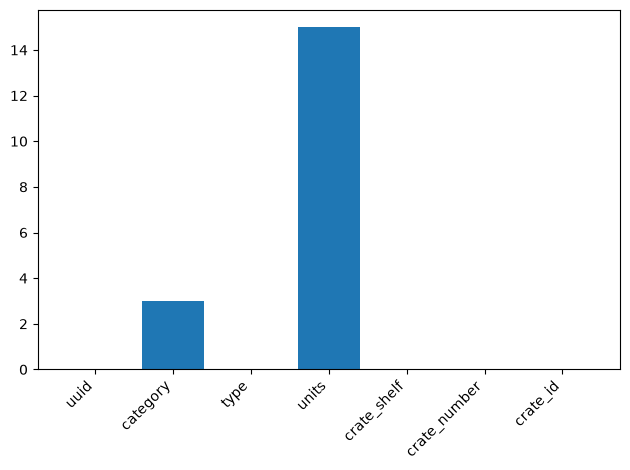

In [22]:
from matplotlib import pyplot as plt

nulls = df.null_count()

plt.bar(nulls.columns, nulls.row(0))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [23]:
df_dropped = df.drop_nulls()

In [26]:
df.transpose()

column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,…,column_78,column_79,column_80,column_81,column_82,column_83,column_84,column_85,column_86,column_87,column_88,column_89,column_90,column_91,column_92,column_93,column_94,column_95,column_96,column_97,column_98,column_99,column_100,column_101,column_102,column_103,column_104,column_105,column_106,column_107,column_108,column_109,column_110,column_111,column_112,column_113,column_114
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""10a0cf40-19db-4e9b-abd7-352552…","""b474a3a9-9e98-4413-9a50-7837e7…","""3227c0c6-0eba-47b8-afb3-cfebe5…","""83673729-a84e-11ed-be1b-d78eb2…","""83673731-a84e-11ed-be1b-d78eb2…","""83673701-a84e-11ed-be1b-d78eb2…","""83673721-a84e-11ed-be1b-d78eb2…","""83673719-a84e-11ed-be1b-d78eb2…","""83673711-a84e-11ed-be1b-d78eb2…","""83673709-a84e-11ed-be1b-d78eb2…","""836736f9-a84e-11ed-be1b-d78eb2…","""836736e9-a84e-11ed-be1b-d78eb2…","""836736f1-a84e-11ed-be1b-d78eb2…","""83673718-a84e-11ed-be1b-d78eb2…","""83673710-a84e-11ed-be1b-d78eb2…","""83673700-a84e-11ed-be1b-d78eb2…","""83673708-a84e-11ed-be1b-d78eb2…","""83673728-a84e-11ed-be1b-d78eb2…","""836736f0-a84e-11ed-be1b-d78eb2…","""836736e8-a84e-11ed-be1b-d78eb2…","""83673730-a84e-11ed-be1b-d78eb2…","""836736f8-a84e-11ed-be1b-d78eb2…","""83673720-a84e-11ed-be1b-d78eb2…","""83673732-a84e-11ed-be1b-d78eb2…","""836736f2-a84e-11ed-be1b-d78eb2…","""83673712-a84e-11ed-be1b-d78eb2…","""8367372a-a84e-11ed-be1b-d78eb2…","""836736fa-a84e-11ed-be1b-d78eb2…","""83673702-a84e-11ed-be1b-d78eb2…","""8367371a-a84e-11ed-be1b-d78eb2…","""836736ea-a84e-11ed-be1b-d78eb2…","""8367370a-a84e-11ed-be1b-d78eb2…","""83673722-a84e-11ed-be1b-d78eb2…","""836736e6-a84e-11ed-be1b-d78eb2…","""836736ee-a84e-11ed-be1b-d78eb2…","""83673706-a84e-11ed-be1b-d78eb2…","""83673716-a84e-11ed-be1b-d78eb2…",…,"""8367370d-a84e-11ed-be1b-d78eb2…","""8367372d-a84e-11ed-be1b-d78eb2…","""83673707-a84e-11ed-be1b-d78eb2…","""836736ef-a84e-11ed-be1b-d78eb2…","""836736ff-a84e-11ed-be1b-d78eb2…","""836736f7-a84e-11ed-be1b-d78eb2…","""8367372f-a84e-11ed-be1b-d78eb2…","""83673717-a84e-11ed-be1b-d78eb2…","""836736e7-a84e-11ed-be1b-d78eb2…","""83673727-a84e-11ed-be1b-d78eb2…","""8367370f-a84e-11ed-be1b-d78eb2…","""8367371f-a84e-11ed-be1b-d78eb2…","""c36fc4ae-9019-4b64-a273-483842…","""6533ec6d-a2f6-449a-b35b-f4cef3…","""0e08722b-7f89-4d20-8ef6-6959e9…","""576410e5-b416-4a69-80c6-7e24f3…","""8598b776-b470-4016-b5ea-f049f6…","""b8f546da-5188-41d4-8c70-7cd180…","""dda7c37f-c741-4e21-8566-2e058a…","""8e53a5b8-78b5-4f0b-a4a4-633382…","""89c0e293-f4b0-453f-9115-1a7a57…","""e355fc40-81a7-4f46-aeef-c25345…","""6c22a6b8-758e-44e3-9183-b1dc05…","""18df1ee1-5627-4db9-b8ec-d650ae…","""4eac56ea-706c-43ba-b177-c6863a…","""5873a7dd-1edd-4a54-9b12-493711…","""f3b61501-59ae-4a7b-afe3-5cef3f…","""fc8a2789-d4bf-47bb-803d-46c0f3…","""5fc38ffc-1a1d-4bdf-9192-fea7d7…","""6aad2124-cdd6-4509-8968-f43fcf…","""ebfc61d1-2230-4f11-8d07-60e60f…","""8843a2ff-4a17-402b-b4d7-0359dd…","""26a37448-a84d-11ed-be1b-d78eb2…","""26a3744a-a84d-11ed-be1b-d78eb2…","""26a37449-a84d-11ed-be1b-d78eb2…","""26a37446-a84d-11ed-be1b-d78eb2…","""26a37447-a84d-11ed-be1b-d78eb2…"
null,null,null,"""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food""","""food"""

In [30]:
## for the screws, replace the words in the units column by numbers

df

uuid,category,type,units,crate_shelf,crate_number,crate_id
str,str,str,str,str,i64,str
"""10a0cf40-19db-4e9b-abd7-352552…",null,"""fish ice cream""","""446""","""E""",7,"""7E"""
"""b474a3a9-9e98-4413-9a50-7837e7…",null,"""fish ice cream""","""184""","""D""",8,"""8D"""
"""3227c0c6-0eba-47b8-afb3-cfebe5…",null,"""fish ice cream""","""135""","""F""",10,"""10F"""
"""83673729-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""","""500.0""","""B""",14,"""14B"""
"""83673731-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""",null,"""A""",14,"""14A"""
…,…,…,…,…,…,…
"""26a37448-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""two""","""A""",3,"""3A"""
"""26a3744a-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""three""","""A""",1,"""1A"""
"""26a37449-a84d-11ed-be1b-d78eb2…","""non-food""","""screws""","""one""","""A""",13,"""13A"""


In [56]:
df['units'].unique().sort()

TypeError: 'Expr' object is not subscriptable

In [104]:
## for the screws, replace the words in the units column by numbers

import polars as pl
df = pl.read_csv('data/cargo.csv')

df = df.with_columns(
    pl.col('units').replace({'one': 1, 'two': 2, 'three': 3})
)

In [105]:
df['units'].unique().sort()

units
str
null
"""1"""
"""135"""
"""184"""
"""2"""
…
"""326"""
"""350"""
"""407"""


In [106]:
## convert the units column to the type int

df = df.with_columns(pl.col('units').cast(pl.Float64).cast(pl.Int64))

In [107]:
df['units'].unique().sort()

units
i64
null
1
2
3
135
…
326
350
407


In [108]:
## fill the missing values in the category column for the ice cream

df.filter(
    pl.col('type') == 'fish ice cream'
).with_columns(
    pl.col('category').fill_null('food')
)

uuid,category,type,units,crate_no,crate_shelf
str,str,str,i64,i64,str
"""b474a3a9-9e98-4413-9a50-7837e7…","""food""","""fish ice cream""",184,8,"""D"""
"""2c4722b7-a144-4579-96c5-2ba7c3…","""food""","""fish ice cream""",233,14,"""A"""
"""3227c0c6-0eba-47b8-afb3-cfebe5…","""food""","""fish ice cream""",135,10,"""F"""
"""a374697b-54cd-4342-9b77-55ae1e…","""food""","""fish ice cream""",326,4,"""B"""
"""cf1961f5-af11-4e10-8e5e-ee9138…","""food""","""fish ice cream""",305,20,"""C"""
"""b928913d-37e8-4ce7-a9a2-25b99e…","""food""","""fish ice cream""",407,16,"""C"""
"""10a0cf40-19db-4e9b-abd7-352552…","""food""","""fish ice cream""",446,7,"""E"""
"""9d96bdef-113e-4fc4-a701-013434…","""food""","""fish ice cream""",350,20,"""D"""
"""31b5f229-33ac-4a3e-aab1-9155cc…","""food""","""fish ice cream""",229,4,"""C"""


In [109]:
df.filter(
    pl.col('type') == 'fish ice cream'
)

uuid,category,type,units,crate_no,crate_shelf
str,str,str,i64,i64,str
"""b474a3a9-9e98-4413-9a50-7837e7…",null,"""fish ice cream""",184,8,"""D"""
"""2c4722b7-a144-4579-96c5-2ba7c3…","""food""","""fish ice cream""",233,14,"""A"""
"""3227c0c6-0eba-47b8-afb3-cfebe5…",null,"""fish ice cream""",135,10,"""F"""
"""a374697b-54cd-4342-9b77-55ae1e…","""food""","""fish ice cream""",326,4,"""B"""
"""cf1961f5-af11-4e10-8e5e-ee9138…","""food""","""fish ice cream""",305,20,"""C"""
"""b928913d-37e8-4ce7-a9a2-25b99e…","""food""","""fish ice cream""",407,16,"""C"""
"""10a0cf40-19db-4e9b-abd7-352552…",null,"""fish ice cream""",446,7,"""E"""
"""9d96bdef-113e-4fc4-a701-013434…","""food""","""fish ice cream""",350,20,"""D"""
"""31b5f229-33ac-4a3e-aab1-9155cc…","""food""","""fish ice cream""",229,4,"""C"""


In [110]:
## fill the missing values in the units column

df

uuid,category,type,units,crate_no,crate_shelf
str,str,str,i64,i64,str
"""fc8a2789-d4bf-47bb-803d-46c0f3…","""non-food""","""spare rubber joints""",252,13,"""A"""
"""8367370c-a84e-11ed-be1b-d78eb2…","""food""","""fine canned fish""",500,15,"""F"""
"""83673704-a84e-11ed-be1b-d78eb2…","""food""","""fine canned fish""",500,12,"""C"""
"""e355fc40-81a7-4f46-aeef-c25345…","""non-food""","""spare rubber joints""",246,5,"""D"""
"""83673716-a84e-11ed-be1b-d78eb2…","""food""","""herring cans""",500,4,"""D"""
…,…,…,…,…,…
"""8367370d-a84e-11ed-be1b-d78eb2…","""food""","""canned fish (500 lbs)""",500,7,"""F"""
"""836736ea-a84e-11ed-be1b-d78eb2…","""food""","""high quality canned fish""",500,3,"""A"""
"""83673728-a84e-11ed-be1b-d78eb2…","""food""","""l33t f15h c4n5""",500,12,"""B"""


In [111]:
df.null_count()

uuid,category,type,units,crate_no,crate_shelf
u32,u32,u32,u32,u32,u32
0,3,0,15,0,0


In [112]:
df.filter(
    pl.col('units').is_null()
)

uuid,category,type,units,crate_no,crate_shelf
str,str,str,i64,i64,str
"""8367372d-a84e-11ed-be1b-d78eb2…","""food""","""canned fish (500 lbs)""",null,15,"""C"""
"""8598b776-b470-4016-b5ea-f049f6…","""non-food""","""spare rubber joints""",null,7,"""E"""
"""8367372f-a84e-11ed-be1b-d78eb2…","""food""","""Canned fish""",null,2,"""A"""
"""8367372b-a84e-11ed-be1b-d78eb2…","""food""","""canned herrings""",null,15,"""E"""
"""c36fc4ae-9019-4b64-a273-483842…","""non-food""","""spare rubber joints""",null,16,"""B"""
…,…,…,…,…,…
"""83673730-a84e-11ed-be1b-d78eb2…","""food""","""l33t f15h c4n5""",null,9,"""F"""
"""83673731-a84e-11ed-be1b-d78eb2…","""food""","""more canned fish""",null,14,"""A"""
"""83673733-a84e-11ed-be1b-d78eb2…","""food""","""canned herrings""",null,20,"""B"""


In [113]:
df.filter(
    pl.col('type') == "spare rubber joints"
)

uuid,category,type,units,crate_no,crate_shelf
str,str,str,i64,i64,str
"""fc8a2789-d4bf-47bb-803d-46c0f3…","""non-food""","""spare rubber joints""",252,13,"""A"""
"""e355fc40-81a7-4f46-aeef-c25345…","""non-food""","""spare rubber joints""",246,5,"""D"""
"""8598b776-b470-4016-b5ea-f049f6…","""non-food""","""spare rubber joints""",null,7,"""E"""
"""18df1ee1-5627-4db9-b8ec-d650ae…","""non-food""","""spare rubber joints""",234,12,"""D"""
"""5fc38ffc-1a1d-4bdf-9192-fea7d7…","""non-food""","""spare rubber joints""",243,5,"""D"""
…,…,…,…,…,…
"""8e53a5b8-78b5-4f0b-a4a4-633382…","""non-food""","""spare rubber joints""",258,2,"""B"""
"""4eac56ea-706c-43ba-b177-c6863a…","""non-food""","""spare rubber joints""",null,5,"""A"""
"""ebfc61d1-2230-4f11-8d07-60e60f…","""non-food""","""spare rubber joints""",232,13,"""E"""


In [114]:
df.filter(
    pl.col('units').is_null()
)['type'].unique()

type
str
"""canned herrings"""
"""high quality canned fish"""
"""fine canned fish"""
"""more canned fish"""
"""spare rubber joints"""
"""Canned fish"""
"""canned fish (500 lbs)"""
"""herring cans"""
"""l33t f15h c4n5"""


In [115]:
median_canned_herrings = df.filter(
    pl.col('type') == "canned herrings"
)['units'].median()
print(median_canned_herrings)

median_canned_fish = df.filter(
    pl.col('type') == "more canned fish"
)['units'].median()
print(median_canned_fish)

median = df['units'].median()
print(median)

500.0
500.0
500.0


In [116]:
df = df.with_columns(
    pl.col('units').fill_null(pl.col('units').median())
)

In [117]:
df.null_count()

uuid,category,type,units,crate_no,crate_shelf
u32,u32,u32,u32,u32,u32
0,3,0,0,0,0


In [118]:
df = df.sort(['type', 'uuid'], descending=[False, False])

In [119]:
df

uuid,category,type,units,crate_no,crate_shelf
str,str,str,f64,i64,str
"""836736e7-a84e-11ed-be1b-d78eb2…","""food""","""Canned fish""",500.0,16,"""E"""
"""836736ef-a84e-11ed-be1b-d78eb2…","""food""","""Canned fish""",500.0,9,"""A"""
"""836736f7-a84e-11ed-be1b-d78eb2…","""food""","""Canned fish""",500.0,4,"""C"""
"""836736ff-a84e-11ed-be1b-d78eb2…","""food""","""Canned fish""",500.0,15,"""A"""
"""83673707-a84e-11ed-be1b-d78eb2…","""food""","""Canned fish""",500.0,17,"""E"""
…,…,…,…,…,…
"""dda7c37f-c741-4e21-8566-2e058a…","""non-food""","""spare rubber joints""",500.0,11,"""A"""
"""e355fc40-81a7-4f46-aeef-c25345…","""non-food""","""spare rubber joints""",246.0,5,"""D"""
"""ebfc61d1-2230-4f11-8d07-60e60f…","""non-food""","""spare rubber joints""",232.0,13,"""E"""
